# Project Deliverable 1

**Student:** Sandeep Parupalli  
**Course:** Advanced Big Data and Data Mining (MSCS-634-B01)  
**Deliverable Focus:** Dataset selection, data cleaning, and exploratory data analysis

## Dataset Loading

This section loads the Online Retail dataset and reviews its basic structure, size, and columns.

In [1]:
import pandas as pd

df = pd.read_excel("Online Retail.xlsx", sheet_name="Online Retail")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
print(df.shape)
print(df.columns)


(541909, 8)
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [4]:
df.isnull().sum()


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
df.duplicated().sum()


np.int64(5268)

## Data Cleaning

This section removes duplicate rows, handles missing values in important fields, checks invalid values, and creates a `TotalSales` feature for analysis.

In [6]:
df_clean = df.drop_duplicates()

print("Original shape:", df.shape)
print("After removing duplicates:", df_clean.shape)


Original shape: (541909, 8)
After removing duplicates: (536641, 8)


In [7]:
df_clean = df_clean.dropna(subset=["Description"])

print("After removing missing Description:", df_clean.shape)


After removing missing Description: (535187, 8)


In [8]:
df_clean = df_clean.dropna(subset=["CustomerID"])

print("After removing missing CustomerID:", df_clean.shape)


After removing missing CustomerID: (401604, 8)


In [9]:
print("Rows with Quantity <= 0:", (df_clean["Quantity"] <= 0).sum())
print("Rows with UnitPrice <= 0:", (df_clean["UnitPrice"] <= 0).sum())


Rows with Quantity <= 0: 8872
Rows with UnitPrice <= 0: 40


In [10]:
df_clean = df_clean[(df_clean["Quantity"] > 0) & (df_clean["UnitPrice"] > 0)]

print("After removing invalid Quantity and UnitPrice:", df_clean.shape)


After removing invalid Quantity and UnitPrice: (392692, 8)


In [11]:
df_clean["TotalSales"] = df_clean["Quantity"] * df_clean["UnitPrice"]

df_clean[["Quantity", "UnitPrice", "TotalSales"]].head()


,Quantity,UnitPrice,TotalSales
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


## Exploratory Data Analysis

This section summarizes the cleaned data and visualizes key patterns in transaction value, seasonality, and country-level sales activity.

In [12]:
df_clean[["Quantity", "UnitPrice", "TotalSales"]].describe()


,Quantity,UnitPrice,TotalSales
count,392692.000000,392692.000000,392692.000000
mean,13.119702,3.125914,22.631500
std,180.492832,22.241836,311.099224
min,1.000000,0.001000,0.001000
25%,2.000000,1.250000,4.950000
50%,6.000000,1.950000,12.450000
75%,12.000000,3.750000,19.800000
max,80995.000000,8142.750000,168469.600000


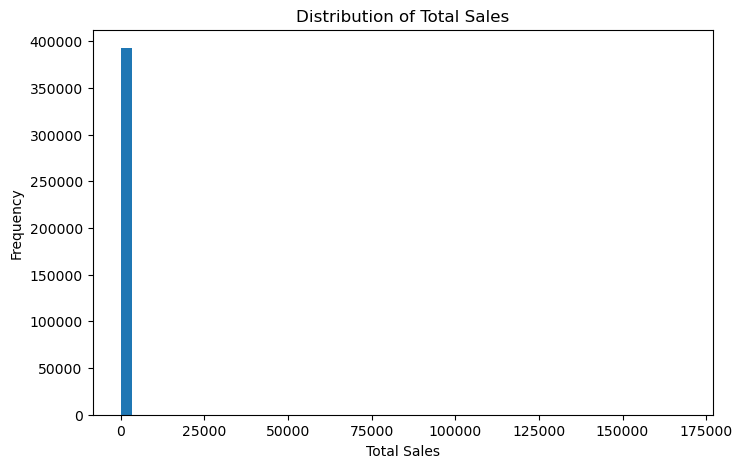

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_clean["TotalSales"], bins=50)
plt.title("Distribution of Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Frequency")
plt.show()


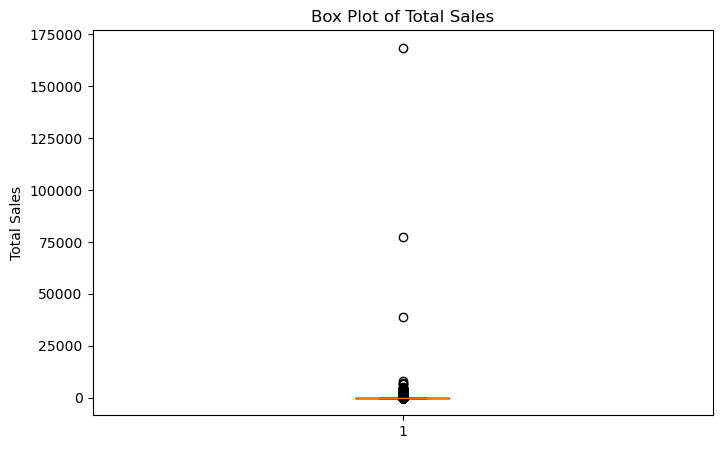

In [14]:
plt.figure(figsize=(8,5))
plt.boxplot(df_clean["TotalSales"])
plt.title("Box Plot of Total Sales")
plt.ylabel("Total Sales")
plt.show()


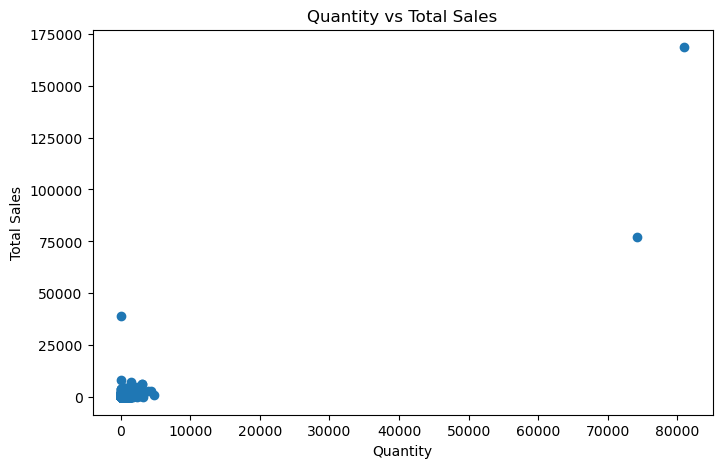

In [15]:
plt.figure(figsize=(8,5))
plt.scatter(df_clean["Quantity"], df_clean["TotalSales"])
plt.title("Quantity vs Total Sales")
plt.xlabel("Quantity")
plt.ylabel("Total Sales")
plt.show()


In [16]:
import numpy as np

df_clean["LogTotalSales"] = np.log1p(df_clean["TotalSales"])

df_clean[["TotalSales", "LogTotalSales"]].head()


,TotalSales,LogTotalSales
0,15.30,2.791165
1,20.34,3.060583
2,22.00,3.135494
3,20.34,3.060583
4,20.34,3.060583


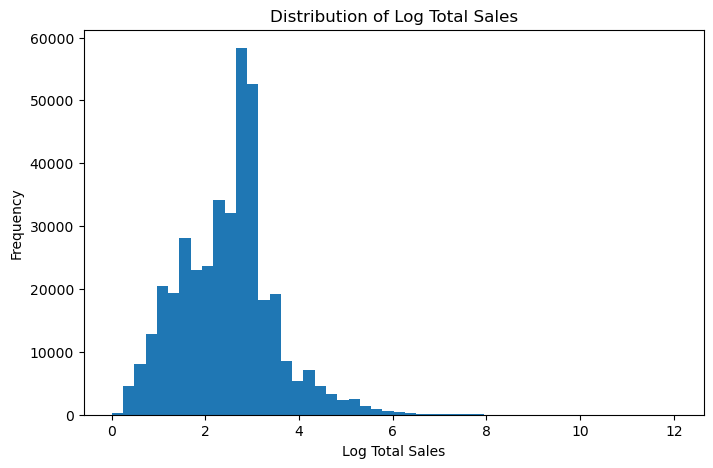

In [17]:
plt.figure(figsize=(8,5))
plt.hist(df_clean["LogTotalSales"], bins=50)
plt.title("Distribution of Log Total Sales")
plt.xlabel("Log Total Sales")
plt.ylabel("Frequency")
plt.show()


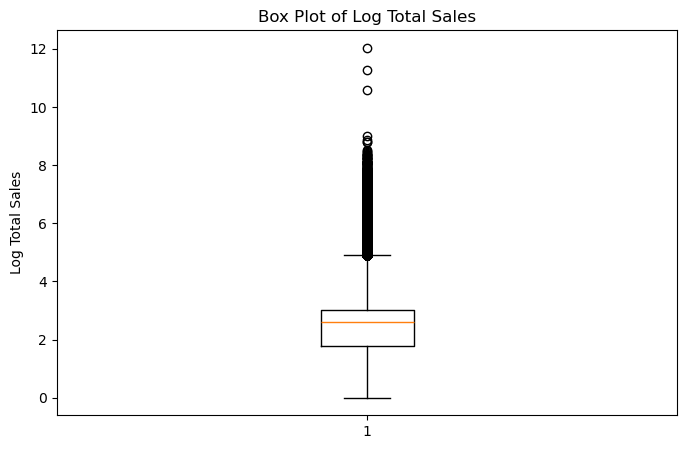

In [18]:
plt.figure(figsize=(8,5))
plt.boxplot(df_clean["LogTotalSales"])
plt.title("Box Plot of Log Total Sales")
plt.ylabel("Log Total Sales")
plt.show()


In [19]:
df_clean["Month"] = df_clean["InvoiceDate"].dt.month

df_clean[["InvoiceDate", "Month"]].head()


,InvoiceDate,Month
0,2010-12-01 08:26:00,12
1,2010-12-01 08:26:00,12
2,2010-12-01 08:26:00,12
3,2010-12-01 08:26:00,12
4,2010-12-01 08:26:00,12


In [20]:
df_clean.groupby("Month")["TotalSales"].sum().sort_index()


Month
1      568101.310
2      446084.920
3      594081.760
4      468374.331
5      677355.150
6      660046.050
7      598962.901
8      644051.040
9      950690.202
10    1035642.450
11    1156205.610
12    1087613.170
Name: TotalSales, dtype: float64

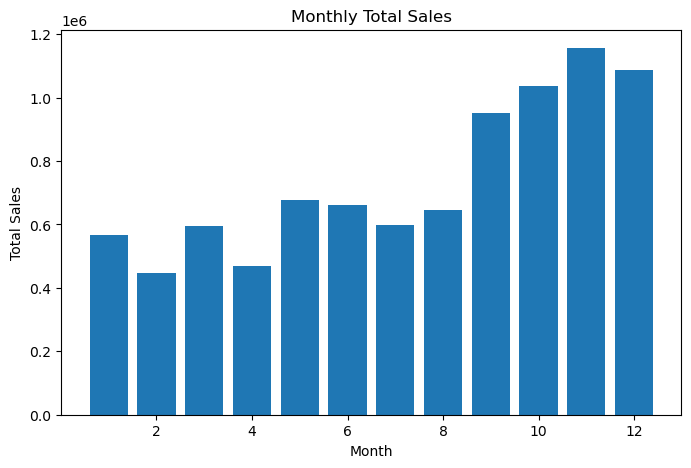

In [21]:
monthly_sales = df_clean.groupby("Month")["TotalSales"].sum().sort_index()

plt.figure(figsize=(8,5))
plt.bar(monthly_sales.index, monthly_sales.values)
plt.title("Monthly Total Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()


In [22]:
country_sales = df_clean.groupby("Country")["TotalSales"].sum().sort_values(ascending=False).head(10)
country_sales


Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: TotalSales, dtype: float64

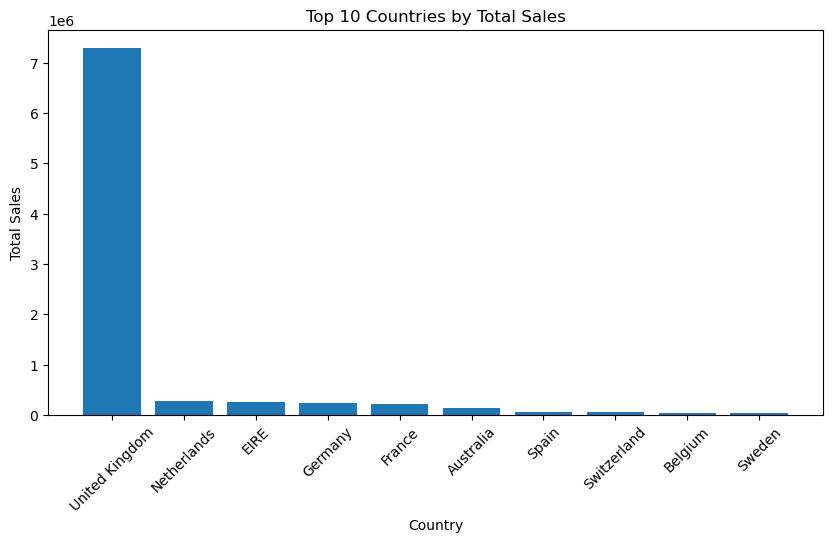

In [23]:
plt.figure(figsize=(10,5))
plt.bar(country_sales.index, country_sales.values)
plt.title("Top 10 Countries by Total Sales")
plt.xlabel("Country")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()


## Deliverable 1 Summary

This notebook version is limited to Project Deliverable 1 work only. It includes dataset selection support through the chosen file, data preparation, and exploratory data analysis, and it excludes later modeling sections such as regression, classification, clustering, and association rule mining.